# Classification examples for chromatography

**HPLC 2026 — Introduction to Artificial Intelligence for Liquid-phase Separations**

**Prepared for the course by Dr. Tijmen S. Bos.**  
This notebook is part of the course **Introduction to Artificial Intelligence for Liquid-phase Separations** and is intended as browser-based teaching material for the HPLC 2026 course.

**Company affiliation.**  
This material is part of **Innovative Data Evaluation And Separations (IDEAS)**, Dr. Tijmen S. Bos's company for data evaluation and separations education/consultancy. Website: **bos-ideas.com**.

**Ownership and use.**  
The educational content in this notebook belongs to **Dr. Tijmen S. Bos / Innovative Data Evaluation And Separations (IDEAS)**, unless a different source is explicitly indicated. The examples are provided for course participation, demonstration, and educational discussion.


**Non-liability and educational-use note.**  
This notebook is provided for course teaching, demonstration, and educational discussion only. The examples use simplified and/or synthetic data and are not validated analytical methods. They should not be used as the sole basis for experimental, regulatory, quality-control, safety, commercial, medical, legal, or financial decisions. Dr. Tijmen S. Bos and Innovative Data Evaluation And Separations (IDEAS) accept no liability for decisions, losses, or damages arising from use, modification, or interpretation of this material. Users remain responsible for validating any method, model, or workflow before practical application.

This notebook is a browser-friendly JupyterLite exercise based on the classification part of the course. It contrasts three supervised classifiers with one unsupervised method:

- **Decision tree** — readable rules, useful for teaching.
- **Random forest** — many trees combined by voting, usually more robust.
- **Support vector machine (SVM)** — margin-based classifier, often strong after PCA/scaling.
- **K-means** — not a classifier; included as an unsupervised comparison.

The synthetic dataset imitates a common chromatographic decision problem:

> Given molecular/sample descriptors, can a model predict a suitable separation mode?

The target classes are **RPLC**, **HILIC**, **NPLC**, and **Ion exchange**.

The data are simulated, so the exercise is safe to distribute and does not need external files.


## Learning goals

After this notebook, participants should be able to:

1. Distinguish **classification** from **clustering**.
2. Explain why **scaling** is important before PCA and SVM.
3. Compare the behaviour of a decision tree, random forest, and SVM.
4. Interpret a confusion matrix in chromatographic language.
5. Explain why unsupervised clusters do not necessarily equal known chemical classes.


In [1]:
# Core scientific stack; all are suitable for a light JupyterLite/Pyodide exercise.
#
# JupyterLite runs Python through Pyodide/WebAssembly. Some scikit-learn calls may trigger
# a harmless threadpoolctl warning about JsProxy.as_object_map(). The warning is unrelated
# to the classification result, so we suppress only that specific Pyodide compatibility warning.
import warnings

warnings.filterwarnings(
    "ignore",
    message=r".*JsProxy\.as_object_map\(\) is deprecated.*",
    category=RuntimeWarning,
)
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module=r"threadpoolctl",
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    adjusted_rand_score,
)

RANDOM_STATE = 7
np.random.seed(RANDOM_STATE)

CLASS_NAMES = np.array(["RPLC", "HILIC", "NPLC", "Ion exchange"])

# IDEAS/HPLC 2026 visual palette.
# Requested colours: #43CEFF, #DB3FC8, #FFC000, and #92D050.
# We use cyan, magenta, gold, and green as the four class colours while
# keeping the older variable names as backward-compatible aliases because
# they are used in later cells.
IDEAS_PRIMARY_CYAN = "#43CEFF"
IDEAS_SECONDARY_CYAN = "#1FB8EA"
IDEAS_MAGENTA = "#DB3FC8"
IDEAS_GOLD = "#FFC000"
IDEAS_DEEP_GOLD = "#D99B00"
IDEAS_GREEN = "#92D050"
IDEAS_DEEP_GREEN = "#6FA83A"
IDEAS_PALE_CYAN = "#D9F7FF"
IDEAS_PALE_CYAN_2 = "#BDEFFF"
IDEAS_PALE_MAGENTA = "#F8D8F4"
IDEAS_PALE_GOLD = "#FFF2BF"
IDEAS_PALE_GOLD_2 = "#FFE49B"
IDEAS_PALE_GREEN = "#E7F5D9"
IDEAS_PALE_GREEN_2 = "#D6EDBC"
IDEAS_TEXT = "#16495A"
IDEAS_GRID = "#E5F8FD"

# Backward-compatible aliases used elsewhere in the notebook.
IDEAS_DARK_BLUE = IDEAS_TEXT
IDEAS_CYAN = IDEAS_PRIMARY_CYAN
IDEAS_PURPLE = IDEAS_MAGENTA
IDEAS_YELLOW = IDEAS_GOLD
IDEAS_RED = IDEAS_GREEN
IDEAS_LIGHT_TEAL = IDEAS_PALE_CYAN
IDEAS_DARK_RED = IDEAS_DEEP_GREEN

CLASS_COLORS = [
    IDEAS_PRIMARY_CYAN,  # RPLC
    IDEAS_MAGENTA,       # HILIC
    IDEAS_GOLD,          # NPLC
    IDEAS_GREEN,         # Ion exchange
]
CLASS_REGION_COLORS = [IDEAS_PALE_CYAN, IDEAS_PALE_MAGENTA, IDEAS_PALE_GOLD, IDEAS_PALE_GREEN]
CLASS_CMAP = ListedColormap(CLASS_COLORS)
REGION_CMAP = ListedColormap(CLASS_REGION_COLORS)
MATRIX_CMAP = LinearSegmentedColormap.from_list(
    "ideas_matrix",
    ["#FFFFFF", IDEAS_PALE_CYAN, IDEAS_PRIMARY_CYAN, IDEAS_MAGENTA],
)

plt.rcParams.update({
    "axes.edgecolor": IDEAS_TEXT,
    "axes.labelcolor": IDEAS_TEXT,
    "axes.titlecolor": IDEAS_TEXT,
    "xtick.color": IDEAS_TEXT,
    "ytick.color": IDEAS_TEXT,
    "grid.color": IDEAS_GRID,
    "grid.alpha": 0.7,
    "legend.frameon": True,
})

# Code-friendly descriptor names. The values are synthetic, but the ranges are chosen
# to be plausible for small-molecule liquid-phase separation examples.
FEATURE_NAMES = [
    "logP",
    "estimated_abs_charge_pH7",
    "polar_surface_area_A2",
    "molecular_mass_Da",
    "nearest_pKa",
    "organic_solubility_score",
    "aqueous_solubility_score",
    "uv254_response_score",
]

# Human-readable labels with units. These are used in plots, tables, and the dashboard.
FEATURE_LABELS = {
    "logP": "logP (unitless)",
    "estimated_abs_charge_pH7": "Estimated |charge| at pH 7 (e)",
    "polar_surface_area_A2": "Polar surface area (Å²)",
    "molecular_mass_Da": "Molecular mass (Da)",
    "nearest_pKa": "Nearest pKa (unitless)",
    "organic_solubility_score": "Organic-solubility score (0–10)",
    "aqueous_solubility_score": "Aqueous-solubility score (0–10)",
    "uv254_response_score": "UV254 response score (0–10)",
}
FEATURE_DISPLAY_NAMES = [FEATURE_LABELS[name] for name in FEATURE_NAMES]


## 1. Generate chromatography-flavoured training data

The feature values are not intended to represent a validated chemical model. They are deliberately constructed so that the classification patterns are plausible and visible:

- **RPLC**: relatively hydrophobic, neutral to weakly charged.
- **HILIC**: polar, often water-compatible.
- **NPLC**: more organic-compatible, weakly charged, intermediate polarity.
- **Ion exchange**: strong charge dominates the decision.

The descriptors are synthetic teaching variables, but their ranges are chosen to be chemically reasonable for small-molecule liquid-phase separations. The class-overlap factor used later is **unitless**: it widens the descriptor distributions and should be interpreted as a pedagogical proxy for noisier, less separable data rather than as detector noise.

| Descriptor | Unit / scale | Teaching range used here | Comment |
|---|---:|---:|---|
| logP | unitless | −2 to 6 | Hydrophobicity descriptor; higher values favour RPLC-like behaviour. |
| Estimated \|charge\| at pH 7 | elementary charge, e | 0 to 2 | Continuous estimate of average absolute ionization at the working pH. |
| Polar surface area | Å² | 5 to 220 | Larger values indicate more polar analytes. |
| Molecular mass | Da | 100 to 750 | Plausible low-to-medium molecular-mass range. |
| Nearest pKa | unitless | 0 to 14 | Simplified acidity/basicity descriptor. |
| Organic-/aqueous-solubility score | 0–10 score | 0 to 10 | Deliberately unitless teaching score, not a measured solubility. |
| UV254 response score | 0–10 score | 0 to 10 | Deliberately unitless teaching score, not an extinction coefficient. |


In [2]:
def make_chromatography_classification_data(
    n_per_class=90,
    noise=0.45,
    random_state=7,
):
    """Create a synthetic chromatographic classification dataset.

    Parameters
    ----------
    n_per_class : int
        Number of samples per class.
    noise : float
        Higher values make the classes overlap more.
    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    X : pandas.DataFrame
        Feature matrix.
    y : numpy.ndarray
        Integer class labels.
    """
    rng = np.random.default_rng(random_state)

    # Means for:
    # logP, estimated absolute charge at pH 7 (e), polar surface area (Å²),
    # molecular mass (Da), nearest pKa, organic-solubility score (0-10),
    # aqueous-solubility score (0-10), UV254 response score (0-10)
    means = {
        "RPLC":         [3.1, 0.25,  48, 360, 6.5, 7.4, 2.4, 7.0],
        "HILIC":        [0.1, 0.35, 135, 310, 5.2, 2.2, 7.5, 5.8],
        "NPLC":         [2.0, 0.15,  78, 330, 6.8, 6.8, 2.0, 4.9],
        "Ion exchange": [0.6, 1.45, 115, 390, 4.2, 2.8, 6.8, 6.1],
    }

    # Feature-specific spread. Noise scales these values.
    base_sd = np.array([0.55, 0.22, 18, 42, 0.9, 0.75, 0.75, 0.8])

    X_parts = []
    y_parts = []

    for class_index, class_name in enumerate(CLASS_NAMES):
        mu = np.array(means[class_name], dtype=float)
        X_class = rng.normal(mu, base_sd * noise, size=(n_per_class, len(FEATURE_NAMES)))

        # Physically sensible clipping for teaching plots.
        X_class[:, 0] = np.clip(X_class[:, 0], -2.0, 6.0)    # logP, unitless
        X_class[:, 1] = np.clip(X_class[:, 1], 0.0, 2.0)     # estimated |charge| at pH 7, e
        X_class[:, 2] = np.clip(X_class[:, 2], 5, 220)       # polar surface area, Å²
        X_class[:, 3] = np.clip(X_class[:, 3], 100, 750)     # molecular mass, Da
        X_class[:, 4] = np.clip(X_class[:, 4], 0, 14)        # nearest pKa, unitless
        X_class[:, 5:] = np.clip(X_class[:, 5:], 0, 10)      # teaching scores, 0-10

        X_parts.append(X_class)
        y_parts.extend([class_index] * n_per_class)

    X = pd.DataFrame(np.vstack(X_parts), columns=FEATURE_NAMES)
    y = np.array(y_parts)
    return X, y


X, y = make_chromatography_classification_data()
data = X.copy()
data["class"] = CLASS_NAMES[y]
data.sample(8, random_state=RANDOM_STATE)


,logP,estimated_abs_charge_pH7,polar_surface_area_A2,molecular_mass_Da,nearest_pKa,organic_solubility_score,aqueous_solubility_score,uv254_response_score,class
60,3.160374,0.246926,49.295690,360.939074,7.272828,7.049362,1.874357,6.635695,RPLC
294,0.518857,1.305843,122.281214,411.785364,5.345759,3.096432,6.599913,5.786201,Ion exchange
351,0.986681,1.335945,93.959696,362.589019,3.789957,2.753534,7.007849,6.047260,Ion exchange
296,0.958281,1.344577,111.295867,363.756753,4.855557,3.237693,7.053896,5.668521,Ion exchange
326,0.848137,1.559410,117.997588,378.493923,4.364738,2.836892,7.082700,5.650319,Ion exchange
73,3.040224,0.125174,42.374890,368.039273,6.660271,7.437205,2.735746,6.721948,RPLC
132,0.348593,0.268673,129.409126,326.721764,5.550184,2.073838,7.122755,5.242092,HILIC
99,0.050585,0.198200,128.875615,292.623638,4.706781,2.346936,7.282234,5.088146,HILIC


## 2. Inspect the raw feature space

Before fitting models, always inspect the data. Here we look at class-wise means to see whether the simulation encodes the intended chromatographic logic.


In [3]:
summary = data.groupby("class")[FEATURE_NAMES].mean().round(2)
summary = summary.rename(columns=FEATURE_LABELS)
summary


,logP (unitless),Estimated |charge| at pH 7 (e),Polar surface area (Å²),Molecular mass (Da),Nearest pKa (unitless),Organic-solubility score (0–10),Aqueous-solubility score (0–10),UV254 response score (0–10)
class,,,,,,,,
HILIC,0.14,0.34,135.90,306.77,5.22,2.20,7.53,5.72
Ion exchange,0.61,1.44,114.27,393.86,4.16,2.78,6.88,6.00
NPLC,2.01,0.16,77.86,329.13,6.82,6.78,2.04,4.89
RPLC,3.07,0.24,48.56,357.24,6.50,7.30,2.35,6.97


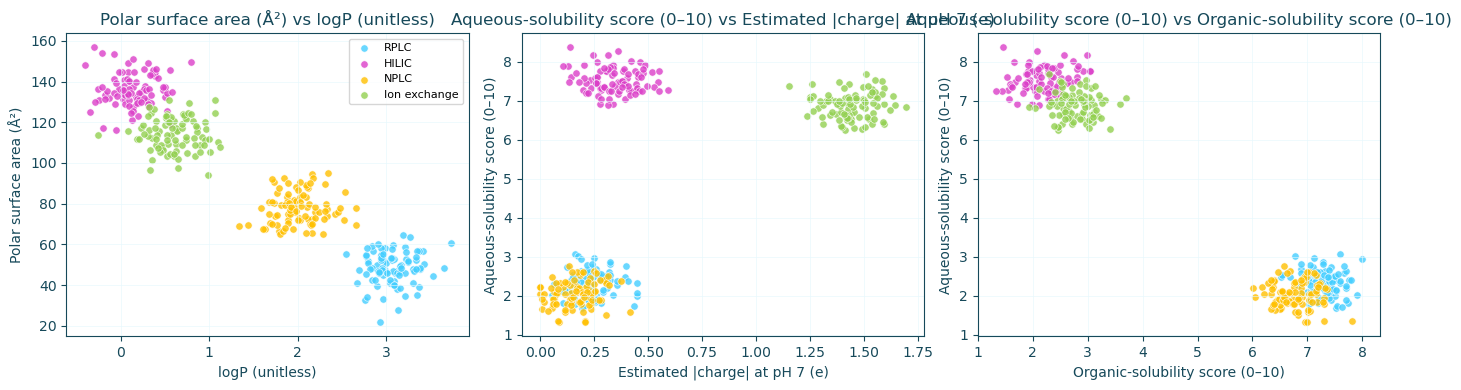

In [4]:
# Simple pair-plot alternative using only matplotlib.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pairs = [
    ("logP", "polar_surface_area_A2"),
    ("estimated_abs_charge_pH7", "aqueous_solubility_score"),
    ("organic_solubility_score", "aqueous_solubility_score"),
]

for ax, (xfeature, yfeature) in zip(axes, pairs):
    for class_index, class_name in enumerate(CLASS_NAMES):
        mask = y == class_index
        ax.scatter(
            X.loc[mask, xfeature],
            X.loc[mask, yfeature],
            s=28,
            alpha=0.80,
            color=CLASS_COLORS[class_index],
            edgecolors="white",
            linewidths=0.5,
            label=class_name,
        )
    ax.set_xlabel(FEATURE_LABELS.get(xfeature, xfeature))
    ax.set_ylabel(FEATURE_LABELS.get(yfeature, yfeature))
    ax.set_title(f"{FEATURE_LABELS.get(yfeature, yfeature)} vs {FEATURE_LABELS.get(xfeature, xfeature)}")

for ax in axes:
    ax.grid(True, linewidth=0.6)
axes[0].legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


## Interpretation of the raw feature plots

These plots show why the problem is suitable for a classification demonstration. The classes are not defined by one descriptor alone. Instead, the model has to combine several chromatographic descriptors:

- **RPLC** samples tend to have higher **logP** and lower aqueous-solubility scores.
- **HILIC** samples tend to have high polar surface area (Å²) and high aqueous-solubility scores.
- **Ion exchange** samples are mainly separated by the estimated absolute charge at pH 7 (e).
- **NPLC** overlaps partly with RPLC and HILIC, which makes it useful for showing classification errors.

In a real chromatographic method-selection problem, this overlap is expected. Separation mode selection is rarely a perfectly clean rule-based decision. The solubility and UV response variables in this notebook are deliberately unitless teaching scores; they are not measured solubilities or molar absorptivities.


## 3. PCA projection

The slides use PCA as a useful starting point before classification. Below, we standardize the variables and project the samples into the first two principal components.

Important point: PCA is not using the class labels. It only rotates the feature space to capture variance.


Explained variance by PC1 and PC2:
PC1: 61.3%
PC2: 24.3%


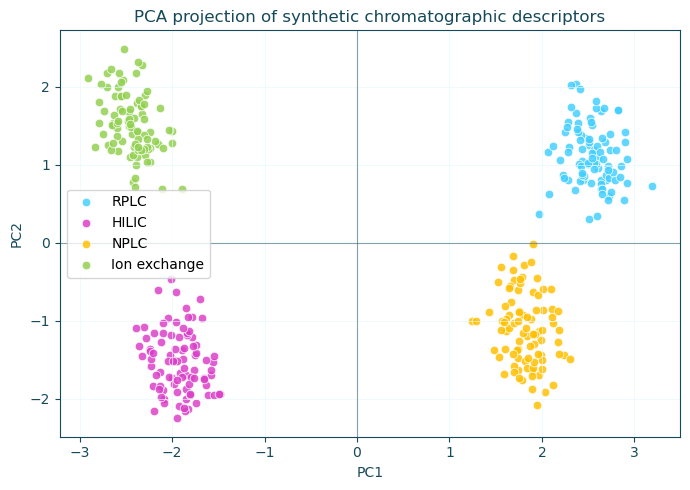

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["class"] = CLASS_NAMES[y]

print("Explained variance by PC1 and PC2:")
for i, value in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {value:.1%}")

plt.figure(figsize=(7, 5))
for class_index, class_name in enumerate(CLASS_NAMES):
    mask = y == class_index
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=38,
        alpha=0.84,
        color=CLASS_COLORS[class_index],
        edgecolors="white",
        linewidths=0.6,
        label=class_name,
    )

plt.axhline(0, linewidth=0.8, color=IDEAS_DARK_BLUE, alpha=0.5)
plt.axvline(0, linewidth=0.8, color=IDEAS_DARK_BLUE, alpha=0.5)
plt.grid(True, linewidth=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of synthetic chromatographic descriptors")
plt.legend()
plt.tight_layout()
plt.show()


## Interpretation of the PCA result

The PCA plot is a compressed view of the descriptor space. PC1 and PC2 are not direct chemical properties; they are mathematical combinations of the original descriptors. However, if the known classes occupy different regions in PCA space, this suggests that the descriptor set contains useful classification information.

Two points are important for discussion:

1. PCA is **unsupervised**. It does not use the class labels when constructing PC1 and PC2.
2. Good separation in PCA space can make classification easier, but poor separation in PCA space does not automatically mean classification is impossible. Later classifiers can still use the full descriptor space.


## 4. Define utility functions for the classifiers

This section only defines reusable Python functions. It is normal that the code cell below does **not** create a plot.

The plots and numerical results appear in the following sections, where the functions are actually called:

- Section 5: decision tree
- Section 6: random forest
- Section 7: SVM
- Section 8: k-means

The utility functions are kept in one place so that the later examples use the same data-generation, scaling, model-fitting, and plotting logic.


In [6]:
def get_classifier(name, max_depth=4, n_estimators=120, C=1.0, gamma="scale", random_state=7):
    if name == "Decision tree":
        return DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)
    if name == "Random forest":
        return RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=random_state,
        )
    if name == "SVM":
        return SVC(kernel="rbf", C=C, gamma=gamma, random_state=random_state)
    raise ValueError(f"Unknown classifier: {name}")


def fit_and_report_classifier(
    classifier_name="SVM",
    noise=0.45,
    test_size=0.30,
    max_depth=4,
    n_estimators=120,
    C=1.0,
    random_state=7,
):
    X, y = make_chromatography_classification_data(
        n_per_class=90,
        noise=noise,
        random_state=random_state,
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state,
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = get_classifier(
        classifier_name,
        max_depth=max_depth,
        n_estimators=n_estimators,
        C=C,
        random_state=random_state,
    )

    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    print(f"Classifier: {classifier_name}")
    print(f"Noise level: {noise}")
    print(f"Test-set accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print()
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

    fig, ax = plt.subplots(figsize=(5.8, 5.2))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=CLASS_NAMES,
        xticks_rotation=35,
        ax=ax,
        colorbar=False,
        cmap=MATRIX_CMAP,
    )
    ax.set_title(f"{classifier_name}: confusion matrix")
    plt.tight_layout()
    plt.show()

    return clf, scaler, X_train, X_test, y_train, y_test


def evaluate_classifier(
    classifier_name="SVM",
    noise=0.45,
    test_size=0.30,
    max_depth=4,
    n_estimators=120,
    C=1.0,
    random_state=7,
):
    """Return accuracy without plotting. Useful for quick parameter comparisons."""
    X, y = make_chromatography_classification_data(
        n_per_class=90,
        noise=noise,
        random_state=random_state,
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state,
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = get_classifier(
        classifier_name,
        max_depth=max_depth,
        n_estimators=n_estimators,
        C=C,
        random_state=random_state,
    )
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    return accuracy_score(y_test, y_pred)


def plot_pca_decision_regions(
    classifier_name="SVM",
    noise=0.45,
    test_size=0.30,
    max_depth=4,
    n_estimators=120,
    C=1.0,
    random_state=7,
):
    X, y = make_chromatography_classification_data(
        n_per_class=90,
        noise=noise,
        random_state=random_state,
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state,
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    pca = PCA(n_components=2, random_state=random_state)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    clf_2d = get_classifier(
        classifier_name,
        max_depth=max_depth,
        n_estimators=n_estimators,
        C=C,
        random_state=random_state,
    )
    clf_2d.fit(X_train_pca, y_train)

    x_min, x_max = X_train_pca[:, 0].min() - 1.0, X_train_pca[:, 0].max() + 1.0
    y_min, y_max = X_train_pca[:, 1].min() - 1.0, X_train_pca[:, 1].max() + 1.0
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250),
    )

    Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(7, 5.8))
    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.70,
        levels=np.arange(len(CLASS_NAMES) + 1) - 0.5,
        cmap=REGION_CMAP,
    )

    for class_index, class_name in enumerate(CLASS_NAMES):
        train_mask = y_train == class_index
        test_mask = y_test == class_index

        plt.scatter(
            X_train_pca[train_mask, 0],
            X_train_pca[train_mask, 1],
            s=30,
            alpha=0.78,
            color=CLASS_COLORS[class_index],
            edgecolors="white",
            linewidths=0.5,
            label=f"{class_name} train",
        )
        plt.scatter(
            X_test_pca[test_mask, 0],
            X_test_pca[test_mask, 1],
            s=76,
            alpha=0.98,
            marker="x",
            color=CLASS_COLORS[class_index],
            linewidths=1.8,
            label=f"{class_name} test",
        )

    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    plt.title(f"{classifier_name} decision regions in PCA space")
    plt.grid(True, linewidth=0.6)
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()



def simple_kmeans_2d(X_2d, n_clusters=4, max_iter=60, random_state=RANDOM_STATE):
    """Small NumPy implementation of k-means for 2D teaching plots.

    This avoids repeated scikit-learn KMeans calls in JupyterLite/Pyodide, which can be
    slow in browser environments. The algorithm is still standard k-means: initialize
    centroids, assign points to the nearest centroid, and update centroids by averaging.
    """
    X_2d = np.asarray(X_2d, dtype=float)
    rng = np.random.default_rng(random_state)

    # Farthest-point initialization: deterministic after the first random point and
    # usually better behaved for small teaching datasets than fully random starts.
    first = int(rng.integers(0, X_2d.shape[0]))
    centers = [X_2d[first]]
    for _ in range(1, n_clusters):
        d2 = np.min(((X_2d[:, None, :] - np.array(centers)[None, :, :]) ** 2).sum(axis=2), axis=1)
        centers.append(X_2d[int(np.argmax(d2))])
    centers = np.array(centers, dtype=float)

    labels = np.zeros(X_2d.shape[0], dtype=int)
    for _ in range(max_iter):
        new_labels = predict_nearest_centers_2d(X_2d, centers)
        new_centers = centers.copy()
        for cluster_id in range(n_clusters):
            mask = new_labels == cluster_id
            if np.any(mask):
                new_centers[cluster_id] = X_2d[mask].mean(axis=0)
        if np.array_equal(new_labels, labels) and np.allclose(new_centers, centers):
            labels = new_labels
            centers = new_centers
            break
        labels = new_labels
        centers = new_centers

    return labels, centers


def predict_nearest_centers_2d(X_2d, centers):
    """Assign 2D points to the nearest centroid."""
    X_2d = np.asarray(X_2d, dtype=float)
    centers = np.asarray(centers, dtype=float)
    distances = ((X_2d[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
    return np.argmin(distances, axis=1)

print("Utility functions loaded. Continue to Section 5 to generate the first classifier plots.")


Utility functions loaded. Continue to Section 5 to generate the first classifier plots.


## How to read the classifier output

For each supervised model, the notebook reports two main results.

**Accuracy** is the fraction of test samples assigned to the correct class. It is useful as a compact score, but it hides which classes are confused.

The **confusion matrix** is usually more informative for chromatography. Rows represent the true class; columns represent the predicted class. Large values on the diagonal are correct predictions. Off-diagonal values show chemically interesting mistakes, for example when an RPLC-like compound is predicted as NPLC because its descriptors are intermediate.


## 5. Decision tree

A decision tree is useful pedagogically because the learned rules can be inspected. This connects naturally to a rule-like chromatographic decision scheme: charge, polarity, solubility, and retention behaviour can drive the proposed mode.


Classifier: Decision tree
Noise level: 0.55
Test-set accuracy: 0.944

              precision    recall  f1-score   support

        RPLC       0.90      1.00      0.95        27
       HILIC       0.96      0.93      0.94        27
        NPLC       1.00      0.85      0.92        27
Ion exchange       0.93      1.00      0.96        27

    accuracy                           0.94       108
   macro avg       0.95      0.94      0.94       108
weighted avg       0.95      0.94      0.94       108



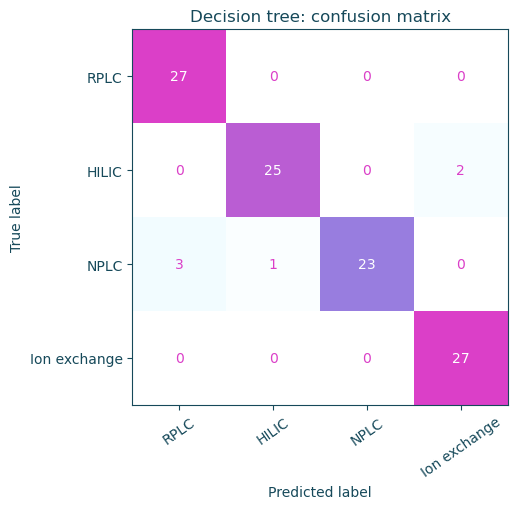

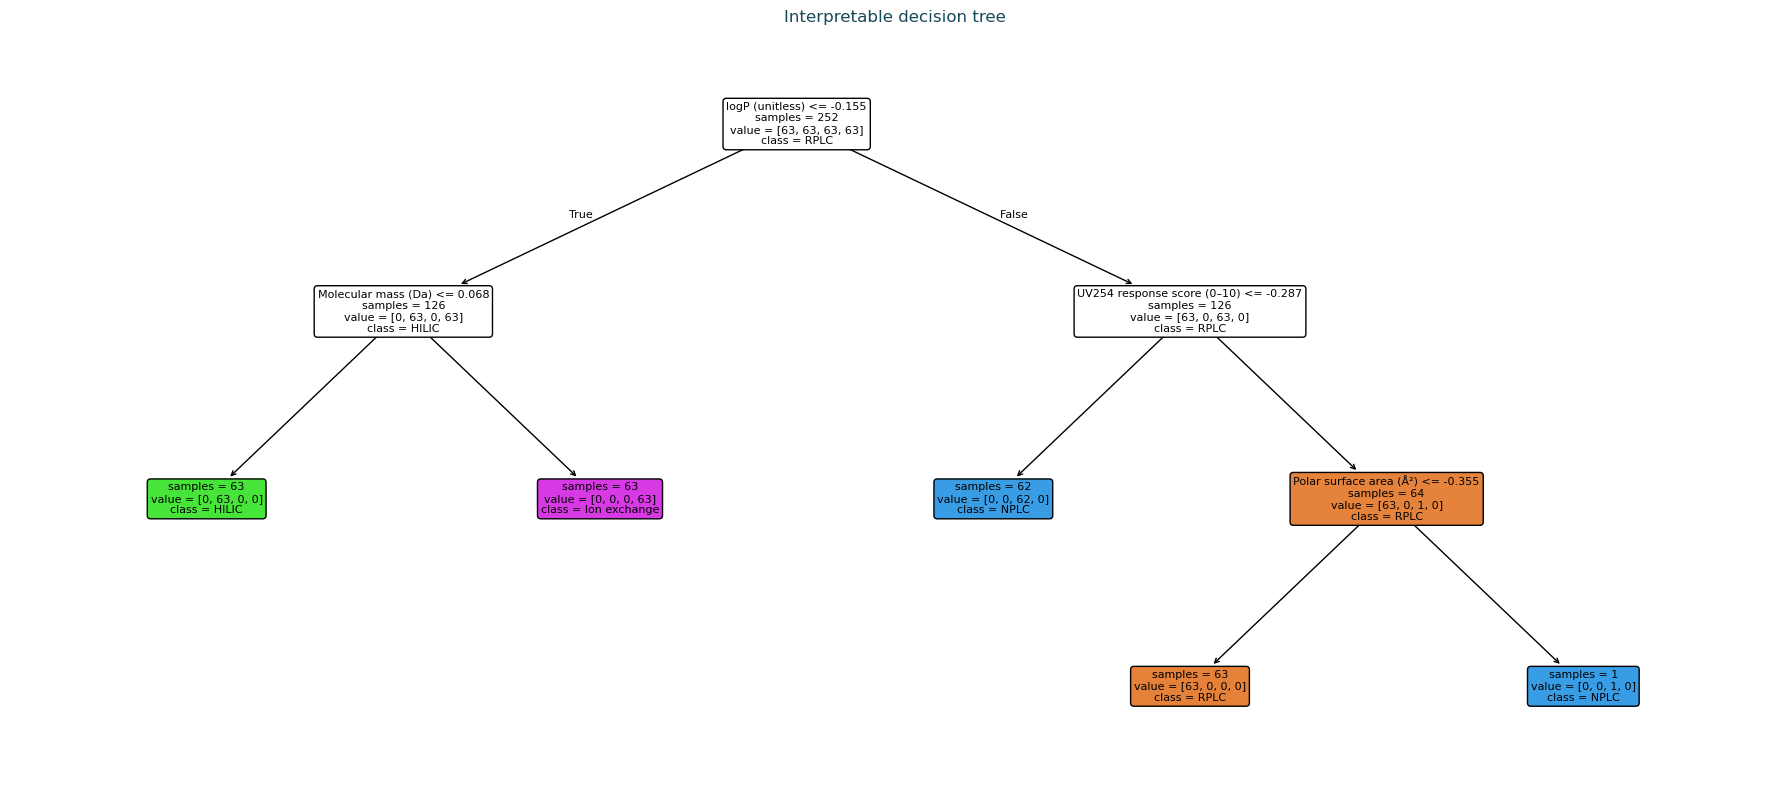

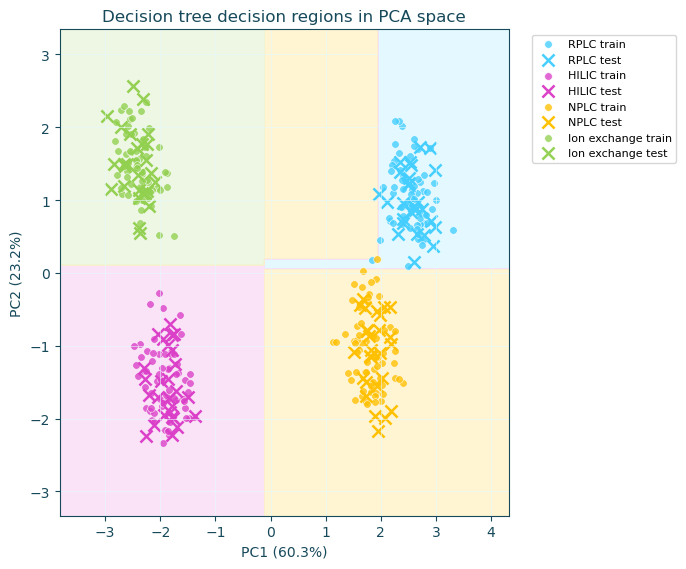

In [7]:
tree_model, tree_scaler, X_train, X_test, y_train, y_test = fit_and_report_classifier(
    classifier_name="Decision tree",
    noise=0.55,
    max_depth=4,
)

plt.figure(figsize=(18, 8))
plot_tree(
    tree_model,
    feature_names=FEATURE_DISPLAY_NAMES,
    class_names=CLASS_NAMES,
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=8,
)
plt.title("Interpretable decision tree")
plt.tight_layout()
plt.show()

plot_pca_decision_regions(
    classifier_name="Decision tree",
    noise=0.55,
    max_depth=4,
)


## Interpretation of the decision tree result

The decision tree result should be read as a set of learned rules. For example, the tree may first split on charge, polarity, or solubility-related descriptors. This resembles an expert chromatographer's decision logic: strongly charged compounds are often separated from neutral hydrophobic compounds before more subtle distinctions are considered.

The main teaching point is the trade-off between interpretability and flexibility. A shallow tree is easy to explain but may miss important class boundaries. A very deep tree can fit the training data closely, but it may overfit noise and become less reliable on new samples.


### Exercise: tree depth

Change `max_depth` above.

- What happens when `max_depth=2`?
- What happens when `max_depth=None`?
- Which setting gives the best balance between interpretability and performance?


## 6. Random forest

A random forest fits many decision trees and combines their votes. This is less transparent than one tree, but it is usually more stable because individual trees make different errors.


Classifier: Random forest
Noise level: 1.0
Test-set accuracy: 0.944

              precision    recall  f1-score   support

        RPLC       0.86      0.93      0.89        27
       HILIC       1.00      1.00      1.00        27
        NPLC       0.92      0.85      0.88        27
Ion exchange       1.00      1.00      1.00        27

    accuracy                           0.94       108
   macro avg       0.95      0.94      0.94       108
weighted avg       0.95      0.94      0.94       108



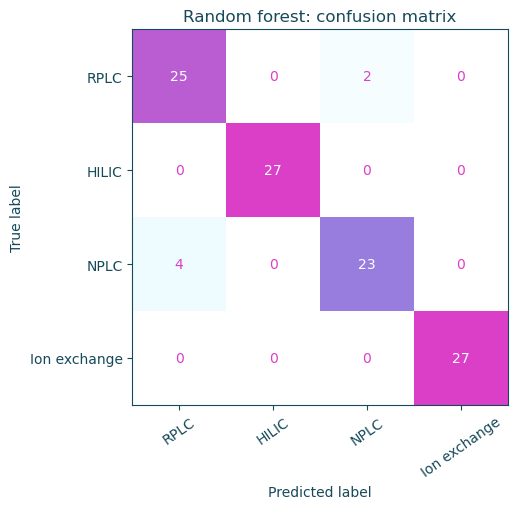

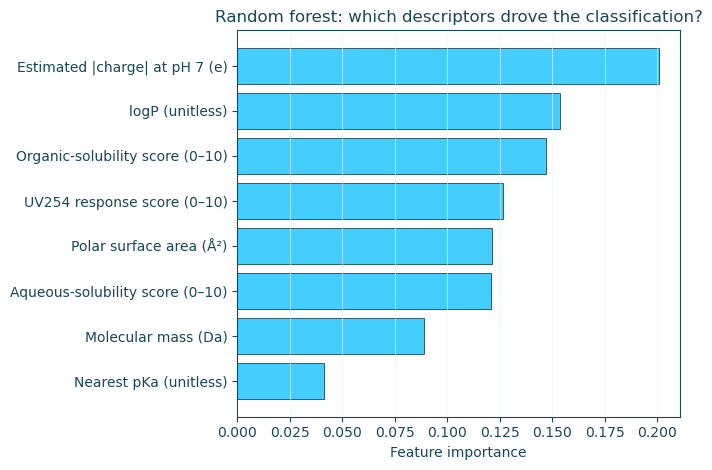

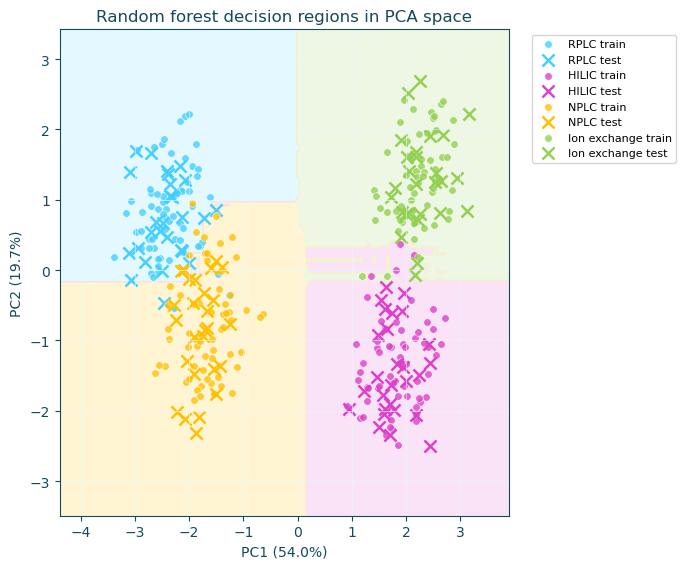

In [8]:
rf_model, rf_scaler, X_train, X_test, y_train, y_test = fit_and_report_classifier(
    classifier_name="Random forest",
    noise=1.00,
    max_depth=5,
    n_estimators=160,
)

# Feature importance from the forest.
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_DISPLAY_NAMES).sort_values(ascending=True)

plt.figure(figsize=(7, 4.8))
plt.barh(importances.index, importances.values, color=IDEAS_CYAN, edgecolor=IDEAS_DARK_BLUE, linewidth=0.6)
plt.xlabel("Feature importance")
plt.title("Random forest: which descriptors drove the classification?")
plt.grid(True, axis="x", linewidth=0.6)
plt.tight_layout()
plt.show()

plot_pca_decision_regions(
    classifier_name="Random forest",
    noise=1.00,
    max_depth=5,
    n_estimators=160,
)


## Interpretation of the random forest result

The random forest usually gives a more stable classification than a single decision tree because it averages the votes of many trees. Individual trees may make different mistakes, but the ensemble often reduces the impact of any one poor split.

The feature-importance plot should be interpreted as a model-based diagnostic, not as proof of causality. If estimated charge at pH 7, polar surface area (Å²), logP, or solubility-like scores are ranked highly, that is chemically plausible for separation-mode selection. However, feature importance can change when variables are correlated, when noise increases, or when a descriptor is removed.


### Exercise: chemically meaningful features

The forest will often rank **estimated charge at pH 7**, **polar surface area**, **logP**, and solubility-like descriptors highly.

Try removing `estimated_abs_charge_pH7` from the data matrix before training. Which class suffers most? Why?


## 7. SVM after scaling and PCA

SVMs are often strong classifiers for medium-sized analytical chemistry datasets. They are particularly sensitive to preprocessing: scaling is normally essential.

Here the visualization is deliberately made in PCA space because it matches the slide concept: samples are first projected to PC1/PC2, then an SVM learns class boundaries.


Classifier: SVM
Noise level: 1.1
Test-set accuracy: 0.963

              precision    recall  f1-score   support

        RPLC       0.90      0.96      0.93        27
       HILIC       1.00      1.00      1.00        27
        NPLC       0.96      0.89      0.92        27
Ion exchange       1.00      1.00      1.00        27

    accuracy                           0.96       108
   macro avg       0.96      0.96      0.96       108
weighted avg       0.96      0.96      0.96       108



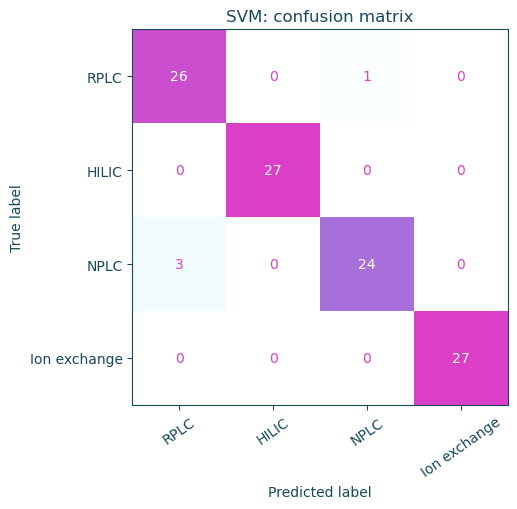

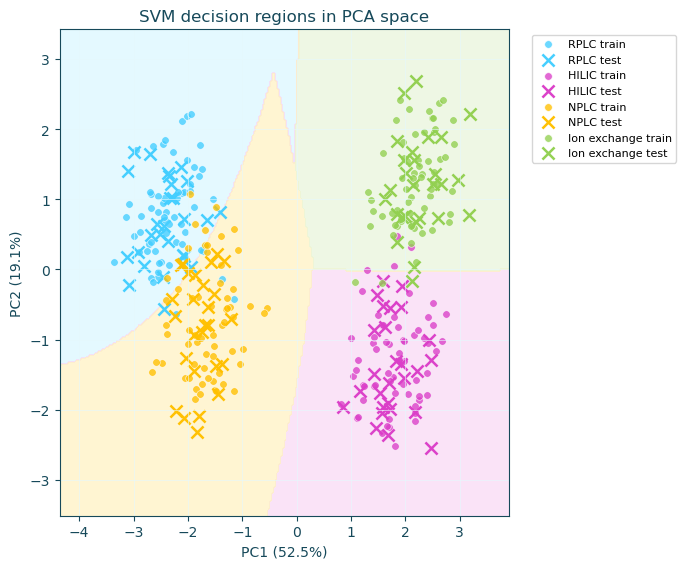

In [9]:
svm_model, svm_scaler, X_train, X_test, y_train, y_test = fit_and_report_classifier(
    classifier_name="SVM",
    noise=1.10,
    C=1.0,
)

plot_pca_decision_regions(
    classifier_name="SVM",
    noise=1.10,
    C=1.0,
)


## Interpretation of the SVM result

The SVM decision regions show how a margin-based classifier separates the classes. In this notebook, the visualization is deliberately restricted to PC1 and PC2 so that the result can be discussed directly next to the PCA slide concept.

The `C` parameter controls the balance between a smooth boundary and a tighter fit to the data. A low `C` accepts more training errors and gives smoother boundaries. A high `C` tries harder to classify the training points correctly, which can produce more complex boundaries and possible overfitting.

The key preprocessing point is scaling. SVMs are distance-based, so descriptors such as molecular mass would otherwise dominate smaller-scale descriptors such as charge or `logP`.


### Exercise: SVM margin and regularization

Change `C` in the SVM cell.

- Low `C`: wider margin, smoother boundary, more tolerance for misclassification.
- High `C`: tighter fit to the training data, potentially more overfitting.

Try `C=0.1`, `C=1`, and `C=25`.


## 8. K-means is not classification

K-means is included deliberately as a contrast with the supervised classifiers above. The algorithm receives only the descriptor matrix; it does **not** receive the known chromatographic class labels. The coloured regions below are therefore **cluster regions**, not class-prediction regions.

For visualization, k-means is fitted in the same two-dimensional PCA space that is plotted. This makes the cluster regions visible and comparable with the PCA-space decision regions used for the supervised models.


Adjusted Rand index versus known classes: 0.802

Cluster membership table:


K-means cluster,0,1,2,3
Known class,,,,
HILIC,87,0,3,0
Ion exchange,3,0,87,0
NPLC,0,20,0,70
RPLC,0,86,0,4


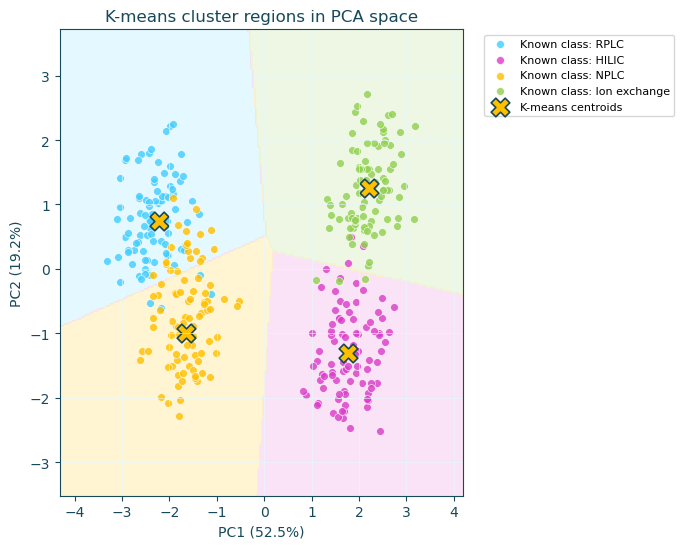

In [10]:
from IPython.display import display

X, y = make_chromatography_classification_data(noise=1.10, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# For this teaching visualization, fit k-means directly in the displayed PCA space.
# The helper is a small NumPy implementation to keep the example responsive in JupyterLite.
# This allows us to draw cluster regions in the same plane as the scatter plot.
clusters, centers_pca = simple_kmeans_2d(X_pca, n_clusters=4, random_state=RANDOM_STATE)

print(f"Adjusted Rand index versus known classes: {adjusted_rand_score(y, clusters):.3f}")
print()
print("Cluster membership table:")
cluster_table = pd.crosstab(
    pd.Series(CLASS_NAMES[y], name="Known class"),
    pd.Series(clusters, name="K-means cluster"),
)
display(cluster_table)

# Match each k-means cluster colour to the dominant known class in that cluster,
# so the shaded cluster regions use the same class colours as the scatter points.
cluster_to_class = {}
for cluster_id in cluster_table.columns:
    dominant_class_name = cluster_table[cluster_id].idxmax()
    dominant_class_index = int(np.where(CLASS_NAMES == dominant_class_name)[0][0])
    cluster_to_class[int(cluster_id)] = dominant_class_index

# Create a grid so the Voronoi-like k-means regions become visible.
x_min, x_max = X_pca[:, 0].min() - 1.0, X_pca[:, 0].max() + 1.0
y_min, y_max = X_pca[:, 1].min() - 1.0, X_pca[:, 1].max() + 1.0
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 250),
    np.linspace(y_min, y_max, 250),
)
Z_clusters = predict_nearest_centers_2d(np.c_[xx.ravel(), yy.ravel()], centers_pca).reshape(xx.shape)
Z = np.vectorize(lambda cid: cluster_to_class.get(int(cid), int(cid)))(Z_clusters)

plt.figure(figsize=(7, 5.6))
plt.contourf(xx, yy, Z, alpha=0.70, levels=np.arange(5) - 0.5, cmap=REGION_CMAP)

for class_index, class_name in enumerate(CLASS_NAMES):
    mask = y == class_index
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=32,
        alpha=0.82,
        color=CLASS_COLORS[class_index],
        edgecolors="white",
        linewidths=0.5,
        label=f"Known class: {class_name}",
    )

plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    marker="X",
    s=180,
    color=IDEAS_YELLOW,
    edgecolor=IDEAS_DARK_BLUE,
    linewidth=1.2,
    label="K-means centroids",
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.title("K-means cluster regions in PCA space")
plt.grid(True, linewidth=0.6)
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


## Interpretation of the k-means result

The shaded background now shows the regions assigned to each k-means cluster in PCA space. These regions are geometric: each point is assigned to the nearest centroid in the displayed PCA plane.

The scatter-point colours still represent the **known chromatographic classes**. This difference is important. If a shaded cluster region contains several known classes, k-means has not recovered the supervised class structure. The adjusted Rand index summarizes this agreement after the fact; it is not used by k-means during fitting.


### Discussion prompt

Use the table above to discuss:

1. Which known classes are recovered well by k-means?
2. Which classes are mixed?
3. Why can an unsupervised cluster be scientifically useful even when it does not match the target labels perfectly?


## 9. Interactive classification exercise

The dashboard below is designed for JupyterLite. It uses ordinary browser controls instead of `ipywidgets`, so students do not need to edit Python code. The background colours show the PCA-space decision regions for supervised classifiers or cluster regions for k-means. The points are the known chromatographic classes.

For speed in JupyterLite, the metric tables and region plots are precomputed on a modest grid of model settings and a smaller browser-friendly training set when this cell is run. The class-overlap slider moves in 0.01 steps, and the dashboard uses the nearest precomputed overlap grid point for model results. The overlap factor is unitless and should be interpreted as a teaching control, not as a physical detector-noise unit.


In [11]:
# Interactive classification exercise for the course exercise.
# Run this cell once. Students do not need to edit the code below.

from IPython.display import HTML, display
from sklearn.metrics import confusion_matrix
import json
import uuid

REGION_NX = 52
REGION_NY = 36
_PCA_SPACE_CACHE = {}


def _exercise_pca_space(noise=1.0, random_state=RANDOM_STATE):
    """Return cached PCA-space data used by the browser dashboard."""
    cache_key = f"{noise:.2f}|{random_state}"
    if cache_key in _PCA_SPACE_CACHE:
        return _PCA_SPACE_CACHE[cache_key]

    X_local, y_local = make_chromatography_classification_data(
        n_per_class=45,
        noise=noise,
        random_state=random_state,
    )
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_local)
    pca = PCA(n_components=2, random_state=random_state)
    X_pca = pca.fit_transform(X_scaled)

    x_pad = max((X_pca[:, 0].max() - X_pca[:, 0].min()) * 0.10, 0.8)
    y_pad = max((X_pca[:, 1].max() - X_pca[:, 1].min()) * 0.10, 0.8)
    x_range = [float(X_pca[:, 0].min() - x_pad), float(X_pca[:, 0].max() + x_pad)]
    y_range = [float(X_pca[:, 1].min() - y_pad), float(X_pca[:, 1].max() + y_pad)]

    rng = np.random.default_rng(random_state)
    selected = []
    for class_index in range(len(CLASS_NAMES)):
        idx = np.flatnonzero(y_local == class_index)
        selected.extend(rng.choice(idx, size=min(45, len(idx)), replace=False).tolist())
    selected = np.array(sorted(selected))

    points = [
        {
            "x": float(X_pca[i, 0]),
            "y": float(X_pca[i, 1]),
            "label": int(y_local[i]),
        }
        for i in selected
    ]

    output = {
        "X_local": X_local,
        "y_local": y_local,
        "X_pca": X_pca,
        "variance": [float(v) for v in pca.explained_variance_ratio_[:2]],
        "x_range": x_range,
        "y_range": y_range,
        "points": points,
    }
    _PCA_SPACE_CACHE[cache_key] = output
    return output


def _region_from_predictor(predictor, x_range, y_range):
    """Convert a PCA-space predictor into compact region labels for the browser canvas."""
    xs = np.linspace(x_range[0], x_range[1], REGION_NX)
    ys = np.linspace(y_range[0], y_range[1], REGION_NY)
    xx, yy = np.meshgrid(xs, ys)
    labels = predictor(np.c_[xx.ravel(), yy.ravel()]).reshape(REGION_NY, REGION_NX)
    return {
        "nx": REGION_NX,
        "ny": REGION_NY,
        "labels": [int(v) for v in labels.ravel()],
    }


def _exercise_supervised_result(
    classifier_name="SVM",
    noise=1.0,
    max_depth=4,
    n_estimators=120,
    C=1.0,
    random_state=RANDOM_STATE,
):
    """Fit a classifier and return compact results for the browser dashboard."""
    X_local, y_local = make_chromatography_classification_data(
        n_per_class=45,
        noise=noise,
        random_state=random_state,
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X_local,
        y_local,
        test_size=0.30,
        stratify=y_local,
        random_state=random_state,
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = get_classifier(
        classifier_name,
        max_depth=max_depth,
        n_estimators=n_estimators,
        C=C,
        random_state=random_state,
    )
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred, labels=list(range(len(CLASS_NAMES))))
    accuracy = float(accuracy_score(y_test, y_pred))

    # Region plot: fit a second, two-dimensional model in PCA space.
    # This is for visualization only; the accuracy above still uses all descriptors.
    space = _exercise_pca_space(noise=noise, random_state=random_state)
    clf_2d = get_classifier(
        classifier_name,
        max_depth=max_depth,
        n_estimators=n_estimators,
        C=C,
        random_state=random_state,
    )
    clf_2d.fit(space["X_pca"], space["y_local"])
    region = _region_from_predictor(clf_2d.predict, space["x_range"], space["y_range"])

    extra = {}
    if classifier_name == "Random forest":
        importance = pd.Series(clf.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
        extra["top_features"] = [
            {"feature": FEATURE_LABELS.get(str(feature), str(feature)), "importance": float(value)}
            for feature, value in importance.head(4).items()
        ]
    elif classifier_name == "Decision tree":
        first_feature_index = int(clf.tree_.feature[0])
        if first_feature_index >= 0:
            extra["first_split"] = FEATURE_LABELS.get(FEATURE_NAMES[first_feature_index], FEATURE_NAMES[first_feature_index])
        else:
            extra["first_split"] = "No split; the tree predicts one class only."

    return {
        "accuracy": accuracy,
        "confusion_matrix": cm.astype(int).tolist(),
        "extra": extra,
        "region": region,
    }


def _exercise_kmeans_result(noise=1.0, random_state=RANDOM_STATE):
    """Run k-means in PCA space and return compact results for the browser dashboard."""
    space = _exercise_pca_space(noise=noise, random_state=random_state)
    X_pca = space["X_pca"]
    y_local = space["y_local"]

    clusters, centers = simple_kmeans_2d(
        X_pca,
        n_clusters=4,
        random_state=random_state,
    )

    table = pd.crosstab(
        pd.Series(CLASS_NAMES[y_local], name="Known class"),
        pd.Series(clusters, name="K-means cluster"),
    ).reindex(index=CLASS_NAMES, fill_value=0)

    # Ensure columns 0..3 are present even if a rare setting produces an empty cluster.
    for cluster_id in range(4):
        if cluster_id not in table.columns:
            table[cluster_id] = 0
    table = table[sorted(table.columns)]

    cluster_to_class = {}
    for cluster_id in table.columns:
        dominant_class_name = table[cluster_id].idxmax()
        dominant_class_index = int(np.where(CLASS_NAMES == dominant_class_name)[0][0])
        cluster_to_class[int(cluster_id)] = dominant_class_index

    region = _region_from_predictor(lambda grid: predict_nearest_centers_2d(grid, centers), space["x_range"], space["y_range"])
    region["labels"] = [int(cluster_to_class.get(int(v), int(v))) for v in region["labels"]]

    return {
        "ari": float(adjusted_rand_score(y_local, clusters)),
        "cluster_table": table.astype(int).values.tolist(),
        "cluster_labels": [str(c) for c in table.columns],
        "centers": [
            {"x": float(center[0]), "y": float(center[1])}
            for center in centers
        ],
        "region": region,
    }


def _exercise_pca_points(noise=1.0, random_state=RANDOM_STATE):
    """Return compact PCA scatter data for the browser canvas."""
    space = _exercise_pca_space(noise=noise, random_state=random_state)
    return {
        "variance": space["variance"],
        "x_range": space["x_range"],
        "y_range": space["y_range"],
        "points": space["points"],
    }


# The dashboard slider moves in 0.01 steps. To keep the notebook responsive in
# JupyterLite, model results are precomputed on a 0.05 noise grid and the
# browser dashboard uses the nearest grid point for the metric tables and region plots.
NOISE_OPTIONS = [0.45, 0.60, 0.75, 0.90, 1.05, 1.20, 1.40]
TREE_DEPTH_OPTIONS = [1, 2, 3, 4, 5, 6, 8, 10, 12]
FOREST_TREE_OPTIONS = [10, 30, 80]
SVM_C_OPTIONS = [0.1, 1.0, 10.0]

exercise_payload = {
    "class_names": [str(x) for x in CLASS_NAMES],
    "feature_names": FEATURE_DISPLAY_NAMES,
    "noise_options": NOISE_OPTIONS,
    "tree_depth_options": TREE_DEPTH_OPTIONS,
    "forest_tree_options": FOREST_TREE_OPTIONS,
    "svm_c_options": SVM_C_OPTIONS,
    "pca": {},
    "results": {},
    "kmeans": {},
}

for noise in NOISE_OPTIONS:
    noise_key = f"{noise:.2f}"
    exercise_payload["pca"][noise_key] = _exercise_pca_points(noise=noise)

    for depth in TREE_DEPTH_OPTIONS:
        key = f"Decision tree|{noise_key}|depth={depth}"
        exercise_payload["results"][key] = _exercise_supervised_result(
            classifier_name="Decision tree",
            noise=noise,
            max_depth=depth,
        )

    # For speed in JupyterLite, the random-forest depth is fixed.
    # The exercise varies the number of trees, while the decision-tree section varies depth.
    for trees in FOREST_TREE_OPTIONS:
        key = f"Random forest|{noise_key}|trees={trees}"
        exercise_payload["results"][key] = _exercise_supervised_result(
            classifier_name="Random forest",
            noise=noise,
            max_depth=5,
            n_estimators=trees,
        )

    for C in SVM_C_OPTIONS:
        key = f"SVM|{noise_key}|C={C:g}"
        exercise_payload["results"][key] = _exercise_supervised_result(
            classifier_name="SVM",
            noise=noise,
            C=C,
        )

    exercise_payload["kmeans"][noise_key] = _exercise_kmeans_result(noise=noise)

container_id = "hplc_classifier_explorer_" + uuid.uuid4().hex[:10]
payload_json = json.dumps(exercise_payload, separators=(",", ":"))

html_template = f"""
<div id="{container_id}" class="hplc-classifier-explorer">
<style>
#{container_id} {{
    font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;
    border: 1px solid #D9F7FF;
    border-radius: 14px;
    padding: 16px;
    background: #ffffff;
    color: #16495A;
    max-width: 100%;
    width: 100%;
    box-sizing: border-box;
    overflow: visible;
}}
.jp-OutputArea-output:has(#{container_id}),
.jp-RenderedHTMLCommon:has(#{container_id}),
.jp-OutputArea-child:has(#{container_id}),
.jp-Cell-outputWrapper:has(#{container_id}),
.jp-Cell-outputArea:has(#{container_id}),
.output_html:has(#{container_id}),
.output_subarea:has(#{container_id}) {{
    height: auto !important;
    max-height: none !important;
    overflow: visible !important;
}}
#{container_id} h3 {{
    margin-top: 0;
}}
#{container_id} .controls {{
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(210px, 1fr));
    gap: 12px;
    margin-bottom: 14px;
}}
#{container_id} label {{
    font-weight: 600;
    font-size: 0.92rem;
}}
#{container_id} select, #{container_id} input[type="range"], #{container_id} textarea {{
    width: 100%;
    box-sizing: border-box;
    margin-top: 5px;
}}
#{container_id} textarea {{
    min-height: 74px;
    resize: vertical;
    border: 1px solid #d0d7de;
    border-radius: 8px;
    padding: 8px;
    font-family: inherit;
}}
#{container_id} .grid {{
    display: grid;
    grid-template-columns: minmax(360px, 1.25fr) minmax(280px, 0.9fr);
    gap: 18px;
    align-items: start;
    overflow: visible;
}}
#{container_id} canvas {{
    max-width: 100%;
    border: 1px solid #D9F7FF;
    border-radius: 10px;
    background: #fbfbfb;
}}
#{container_id} .card {{
    border: 1px solid #d8dee4;
    border-radius: 10px;
    padding: 12px;
    background: #F7FBFC;
    margin-bottom: 12px;
}}
#{container_id} table {{
    border-collapse: collapse;
    width: 100%;
    font-size: 0.9rem;
}}
#{container_id} th, #{container_id} td {{
    border: 1px solid #d8dee4;
    padding: 6px 8px;
    text-align: center;
}}
#{container_id} th {{
    background: #D9F7FF;
}}
#{container_id} .note {{
    font-size: 0.92rem;
    line-height: 1.45;
}}
#{container_id} .button-row {{
    display: flex;
    gap: 10px;
    flex-wrap: wrap;
    margin-top: 10px;
}}
#{container_id} button {{
    border: 1px solid #8c959f;
    border-radius: 8px;
    background: #F7FBFC;
    padding: 8px 12px;
    cursor: pointer;
}}
#{container_id} button:hover {{
    background: #D9F7FF;
}}
#{container_id} .hidden {{
    display: none;
}}
@media (max-width: 800px) {{
    #{container_id} .grid {{
        grid-template-columns: 1fr;
    }}
}}

#{container_id} [data-suggested-answers] {{
    border-left: 4px solid #FFC000;
    background: #FFF2BF;
    border-color: #FFC000;
}}
#{container_id} [data-suggested-answers] h4 {{
    margin-top: 0;
}}
#{container_id} [data-suggested-content] ol {{
    margin-top: 0.5rem;
    padding-left: 1.2rem;
}}
#{container_id} [data-suggested-content] li {{
    margin-bottom: 0.55rem;
}}

</style>

<h3>Interactive classification exercise</h3>
<p class="note"><strong>IDEAS — Innovative Data Evaluation And Separations</strong> · bos-ideas.com</p>
<p class="note">
Use the controls to compare supervised classification models with k-means clustering.
The background shows the PCA-space decision region or cluster region. The points show the known chromatographic classes.
The descriptor values use realistic units where applicable; solubility and UV response are unitless teaching scores.
This exercise is part of Dr. Tijmen S. Bos's course material for Innovative Data Evaluation And Separations (IDEAS), bos-ideas.com.
The metrics update automatically. Write your answers in the boxes at the bottom.
</p>

<div class="controls">
    <label>
        Method
        <select data-control="model">
            <option>Decision tree</option>
            <option>Random forest</option>
            <option>SVM</option>
            <option>K-means</option>
        </select>
    </label>

    <label>
        Class-overlap factor, unitless: <span data-value="noise">1.10</span>
        <input data-control="noise" type="range" min="0.45" max="1.40" step="0.01" value="1.10">
        <div class="note">Slider step = 0.01. This factor widens the synthetic descriptor distributions; metrics and regions use the nearest precomputed grid point for speed.</div>
    </label>

    <label data-control-group="depth">
        Decision-tree depth
        <select data-control="depth">
            <option value="1">1</option>
            <option value="2">2</option>
            <option value="3">3</option>
            <option value="4" selected>4</option>
            <option value="5">5</option>
            <option value="6">6</option>
            <option value="8">8</option>
            <option value="10">10</option>
            <option value="12">12</option>
        </select>
    </label>

    <label data-control-group="trees">
        Number of trees
        <select data-control="trees">
            <option value="10">10</option>
            <option value="30" selected>30</option>
            <option value="80">80</option>
        </select>
    </label>

    <label data-control-group="svmC">
        SVM regularization, C
        <select data-control="svmC">
            <option value="0.1">0.1</option>
            <option value="1" selected>1</option>
            <option value="10">10</option>
        </select>
    </label>
</div>

<div class="grid">
    <div>
        <canvas width="680" height="460" data-role="plot"></canvas>
        <p class="note" data-role="plot-caption"></p>
    </div>
    <div>
        <div class="card" data-role="metric-card"></div>
        <div class="card" data-role="matrix-card"></div>
        <div class="card" data-role="interpretation-card"></div>
    </div>
</div>

<div class="card">
    <h4>Course exercise answers</h4>
    <p class="note">
    These answer boxes are saved in this browser tab. Use “Download answers” before closing the notebook if you want to keep them.
    </p>

    <label>
        1. Is the selected method supervised classification or unsupervised clustering? How do you know?
        <textarea data-answer="q1" placeholder="Write your answer here."></textarea>
    </label>

    <label>
        2. Which classes are most often confused in the selected scenario? What chromatographic interpretation could explain that?
        <textarea data-answer="q2" placeholder="Use the confusion matrix or k-means cluster table."></textarea>
    </label>

    <label>
        3. Increase the noise/class-overlap slider. What happens to the performance metric and to the region boundaries?
        <textarea data-answer="q3" placeholder="Compare at least two noise settings."></textarea>
    </label>

    <label>
        4. For an HPLC method-development assistant, which method would you choose first: decision tree, random forest, SVM, or k-means? Justify your choice.
        <textarea data-answer="q4" placeholder="Balance interpretability, robustness, and whether labels are available."></textarea>
    </label>

    <div class="button-row">
        <button type="button" data-action="show-suggested">Show suggested answers</button>
        <button type="button" data-action="use-suggested">Use suggested answers in boxes</button>
        <button type="button" data-action="download">Download answers</button>
        <button type="button" data-action="copy">Copy answers to clipboard</button>
        <button type="button" data-action="clear">Clear answer boxes</button>
    </div>

    <div class="card hidden" data-suggested-answers>
        <h4>Suggested answers</h4>
        <p class="note">These are model answers for discussion. They update when you change the selected method or parameters.</p>
        <div class="note" data-suggested-content></div>
    </div>
</div>

<script>
(() => {{
    const root = document.getElementById("{container_id}");
    const payload = {payload_json};

    const classNames = payload.class_names;
    const noiseOptions = payload.noise_options;
    const colors = ["#43CEFF", "#DB3FC8", "#FFC000", "#92D050"];
    const regionColors = ["rgba(67,206,255,0.18)", "rgba(219,63,200,0.16)", "rgba(255,192,0,0.18)", "rgba(146,208,80,0.18)"];
    const storageKey = "{container_id}_answers";

    const get = (selector) => root.querySelector(selector);
    const getAll = (selector) => Array.from(root.querySelectorAll(selector));

    function expandNotebookOutputArea() {{
        // Keep normal notebook/page scrolling intact.
        // This function only touches the output wrappers around this one dashboard.
        // It deliberately avoids document/body/notebook viewport containers.
        const safeSelectors = [
            ".jp-OutputArea-output",
            ".jp-RenderedHTMLCommon",
            ".jp-OutputArea-child",
            ".jp-Cell-outputWrapper",
            ".jp-Cell-outputArea",
            ".output_html",
            ".output_subarea"
        ];

        const stopSelectors = [
            ".jp-Notebook",
            ".jp-NotebookPanel-notebook",
            ".jp-WindowedPanel-viewport",
            ".jp-WindowedPanel-outer",
            ".jp-MainAreaWidget"
        ];

        function expandElement(el) {{
            if (!el || !el.style) return;
            el.style.setProperty("height", "auto", "important");
            el.style.setProperty("max-height", "none", "important");
            el.style.setProperty("overflow", "visible", "important");
            el.style.setProperty("overflow-y", "visible", "important");
            el.style.setProperty("contain", "none", "important");
        }}

        // First expand any known wrappers that directly contain this dashboard.
        safeSelectors.forEach(sel => {{
            const wrapper = root.closest(sel);
            expandElement(wrapper);
        }});

        // Then walk upward, but stop before reaching the notebook viewport or page.
        // This catches JupyterLite/Lumino wrappers whose class names vary by version.
        let node = root.parentElement;
        for (let i = 0; i < 18 && node; i++) {{
            if (stopSelectors.some(sel => node.matches && node.matches(sel))) break;
            if (node === document.body || node === document.documentElement) break;

            const className = String(node.className || "");
            const looksLikeOutputWrapper =
                className.includes("Output") ||
                className.includes("output") ||
                className.includes("RenderedHTML") ||
                className.includes("Cell-output") ||
                className.includes("lm-Widget");

            if (looksLikeOutputWrapper) expandElement(node);
            node = node.parentElement;
        }}
    }}

    expandNotebookOutputArea();

    // Some JupyterLite builds reapply output sizing after rendering. Re-expand once
    // after layout and again whenever the dashboard size changes.
    setTimeout(expandNotebookOutputArea, 50);
    setTimeout(expandNotebookOutputArea, 400);
    if (window.ResizeObserver) {{
        const resizeObserver = new ResizeObserver(() => expandNotebookOutputArea());
        resizeObserver.observe(root);
    }}

    const controls = {{
        model: get('[data-control="model"]'),
        noise: get('[data-control="noise"]'),
        depth: get('[data-control="depth"]'),
        trees: get('[data-control="trees"]'),
        svmC: get('[data-control="svmC"]'),
    }};

    function currentNoise() {{
        return Math.round(Number(controls.noise.value) * 100) / 100;
    }}

    function nearestNoise() {{
        const value = currentNoise();
        let nearest = noiseOptions[0];
        let bestDistance = Math.abs(value - nearest);
        for (const candidate of noiseOptions) {{
            const distance = Math.abs(value - candidate);
            if (distance < bestDistance) {{
                nearest = candidate;
                bestDistance = distance;
            }}
        }}
        return nearest;
    }}

    function noiseKey() {{
        return nearestNoise().toFixed(2);
    }}

    function resultKey() {{
        const model = controls.model.value;
        const nk = noiseKey();
        if (model === "Decision tree") {{
            return `Decision tree|${{nk}}|depth=${{controls.depth.value}}`;
        }}
        if (model === "Random forest") {{
            return `Random forest|${{nk}}|trees=${{controls.trees.value}}`;
        }}
        if (model === "SVM") {{
            return `SVM|${{nk}}|C=${{Number(controls.svmC.value).toString()}}`;
        }}
        return null;
    }}

    function activeResult() {{
        if (controls.model.value === "K-means") return payload.kmeans[noiseKey()];
        return payload.results[resultKey()];
    }}

    function formatNumber(value, digits = 3) {{
        return Number(value).toFixed(digits);
    }}

    function setControlVisibility() {{
        const model = controls.model.value;
        root.querySelector('[data-control-group="depth"]').classList.toggle("hidden", model !== "Decision tree");
        root.querySelector('[data-control-group="trees"]').classList.toggle("hidden", model !== "Random forest");
        root.querySelector('[data-control-group="svmC"]').classList.toggle("hidden", model !== "SVM");
    }}

    function drawPcaPlot(result) {{
        const canvas = get('[data-role="plot"]');
        const ctx = canvas.getContext("2d");
        const pca = payload.pca[noiseKey()];
        const points = pca.points;
        const region = result.region;
        const w = canvas.width;
        const h = canvas.height;
        const pad = 58;
        const xMin = pca.x_range[0];
        const xMax = pca.x_range[1];
        const yMin = pca.y_range[0];
        const yMax = pca.y_range[1];

        ctx.clearRect(0, 0, w, h);
        ctx.fillStyle = "#fbfbfb";
        ctx.fillRect(0, 0, w, h);

        function sx(x) {{
            return pad + ((x - xMin) / (xMax - xMin)) * (w - 2*pad);
        }}
        function sy(y) {{
            return h - pad - ((y - yMin) / (yMax - yMin)) * (h - 2*pad);
        }}

        // Decision or cluster regions.
        if (region && region.labels) {{
            const nx = region.nx;
            const ny = region.ny;
            const dx = (xMax - xMin) / (nx - 1);
            const dy = (yMax - yMin) / (ny - 1);
            for (let j = 0; j < ny - 1; j++) {{
                for (let i = 0; i < nx - 1; i++) {{
                    const label = region.labels[j * nx + i];
                    ctx.fillStyle = regionColors[label % regionColors.length];
                    const x0 = xMin + i * dx;
                    const x1 = xMin + (i + 1) * dx;
                    const y0 = yMin + j * dy;
                    const y1 = yMin + (j + 1) * dy;
                    ctx.fillRect(sx(x0), sy(y1), Math.max(1, sx(x1) - sx(x0) + 1), Math.max(1, sy(y0) - sy(y1) + 1));
                }}
            }}
        }}

        // Grid lines
        ctx.strokeStyle = "#D9F7FF";
        ctx.lineWidth = 0.8;
        for (let i = 1; i <= 4; i++) {{
            const gx = pad + i * (w - 2*pad) / 5;
            const gy = pad + i * (h - 2*pad) / 5;
            ctx.beginPath();
            ctx.moveTo(gx, pad);
            ctx.lineTo(gx, h - pad);
            ctx.moveTo(pad, gy);
            ctx.lineTo(w - pad, gy);
            ctx.stroke();
        }}

        // Axes
        ctx.strokeStyle = "#16495A";
        ctx.lineWidth = 1;
        ctx.beginPath();
        ctx.moveTo(pad, h - pad);
        ctx.lineTo(w - pad, h - pad);
        ctx.moveTo(pad, pad);
        ctx.lineTo(pad, h - pad);
        ctx.stroke();

        // Known-class points.
        for (const p of points) {{
            ctx.beginPath();
            ctx.fillStyle = colors[p.label % colors.length];
            ctx.globalAlpha = 0.82;
            ctx.arc(sx(p.x), sy(p.y), 4.4, 0, 2 * Math.PI);
            ctx.fill();
            ctx.strokeStyle = "rgba(255,255,255,0.8)";
            ctx.lineWidth = 0.8;
            ctx.stroke();
        }}
        ctx.globalAlpha = 1;

        // K-means centroids when relevant.
        if (controls.model.value === "K-means" && result.centers) {{
            for (const center of result.centers) {{
                const x = sx(center.x);
                const y = sy(center.y);
                ctx.strokeStyle = "#16495A";
                ctx.lineWidth = 2.2;
                ctx.beginPath();
                ctx.moveTo(x - 8, y - 8);
                ctx.lineTo(x + 8, y + 8);
                ctx.moveTo(x + 8, y - 8);
                ctx.lineTo(x - 8, y + 8);
                ctx.stroke();
            }}
        }}

        // Titles and labels
        ctx.fillStyle = "#16495A";
        ctx.font = "16px sans-serif";
        const regionType = controls.model.value === "K-means" ? "cluster regions" : "decision regions";
        ctx.fillText(`${{controls.model.value}} ${{regionType}} at overlap factor = ${{currentNoise().toFixed(2)}}`, pad, 28);
        ctx.font = "13px sans-serif";
        ctx.fillText(`PC1 (${{(pca.variance[0] * 100).toFixed(1)}}%)`, w / 2 - 35, h - 16);
        ctx.save();
        ctx.translate(18, h / 2 + 45);
        ctx.rotate(-Math.PI / 2);
        ctx.fillText(`PC2 (${{(pca.variance[1] * 100).toFixed(1)}}%)`, 0, 0);
        ctx.restore();

        // Legend
        let lx = w - pad - 155;
        let ly = pad + 5;
        ctx.font = "12px sans-serif";
        for (let i = 0; i < classNames.length; i++) {{
            ctx.fillStyle = colors[i % colors.length];
            ctx.beginPath();
            ctx.arc(lx, ly + i * 22, 5, 0, 2*Math.PI);
            ctx.fill();
            ctx.fillStyle = "#16495A";
            ctx.fillText(classNames[i], lx + 12, ly + 4 + i * 22);
        }}
        if (controls.model.value === "K-means") {{
            ctx.strokeStyle = "#16495A";
            ctx.lineWidth = 2;
            ctx.beginPath();
            ctx.moveTo(lx - 6, ly + 91);
            ctx.lineTo(lx + 6, ly + 103);
            ctx.moveTo(lx + 6, ly + 91);
            ctx.lineTo(lx - 6, ly + 103);
            ctx.stroke();
            ctx.fillStyle = "#16495A";
            ctx.fillText("Centroid", lx + 12, ly + 101);
        }}

        const visualNote = controls.model.value === "K-means"
            ? "Background colours are k-means cluster regions; point colours are known classes."
            : "Background colours are PCA-space decision regions; point colours are known classes.";
        get('[data-role="plot-caption"]').textContent =
            `${{visualNote}} Results use the nearest precomputed overlap grid point (${{nearestNoise().toFixed(2)}}).`;
    }}

    function matrixTable(matrix, rowLabels, colLabels) {{
        let html = "<table><thead><tr><th></th>";
        for (const col of colLabels) html += `<th>${{col}}</th>`;
        html += "</tr></thead><tbody>";
        for (let i = 0; i < matrix.length; i++) {{
            html += `<tr><th>${{rowLabels[i]}}</th>`;
            for (let j = 0; j < matrix[i].length; j++) {{
                const value = matrix[i][j];
                const isDiagonal = i === j && rowLabels.length === colLabels.length;
                html += `<td style="${{isDiagonal ? "font-weight:700;background:#ffffff;" : ""}}">${{value}}</td>`;
            }}
            html += "</tr>";
        }}
        html += "</tbody></table>";
        return html;
    }}

    function mostConfusedPair(cm) {{
        let maxValue = -1;
        let pair = null;
        for (let i = 0; i < cm.length; i++) {{
            for (let j = 0; j < cm[i].length; j++) {{
                if (i !== j && cm[i][j] > maxValue) {{
                    maxValue = cm[i][j];
                    pair = [i, j];
                }}
            }}
        }}
        if (maxValue <= 0 || pair === null) {{
            return "No off-diagonal confusion in this test split.";
        }}
        return `${{classNames[pair[0]]}} predicted as ${{classNames[pair[1]]}} (${{maxValue}} test samples).`;
    }}

    function supervisedInterpretation(model, result) {{
        const acc = result.accuracy;
        let performance;
        if (acc >= 0.95) performance = "The classes are separated very well in this scenario.";
        else if (acc >= 0.85) performance = "The model performs well, but some boundary cases remain.";
        else if (acc >= 0.70) performance = "The model is usable for teaching, but class overlap is visibly affecting predictions.";
        else performance = "The model struggles because the synthetic classes overlap strongly.";

        let modelText = "";
        if (model === "Decision tree") {{
            modelText = `Decision trees are interpretable. The first split here uses <strong>${{result.extra.first_split || "an unavailable feature"}}</strong>, which can be discussed chemically as a rule-like descriptor threshold.`;
        }} else if (model === "Random forest") {{
            const top = (result.extra.top_features || []).map(x => `${{x.feature}}`).join(", ");
            modelText = `Random forests are usually more robust than one tree. The strongest descriptors in this run are: <strong>${{top}}</strong>.`;
        }} else {{
            modelText = "The SVM gives a flexible margin-based boundary after scaling. It can perform strongly, but the boundary is less directly interpretable than a tree.";
        }}

        return `<p>${{performance}}</p><p>${{modelText}}</p><p><strong>Most confused pair:</strong> ${{mostConfusedPair(result.confusion_matrix)}}</p><p class="note">The shaded regions are fitted in two-dimensional PCA space for visualization. The accuracy and confusion matrix use the full descriptor set.</p>`;
    }}

    function kmeansInterpretation(result) {{
        const ari = result.ari;
        let text;
        if (ari >= 0.85) text = "K-means recovered groups that closely resemble the known classes.";
        else if (ari >= 0.55) text = "K-means recovered part of the class structure, but some chemically distinct classes are mixed.";
        else text = "K-means does not recover the known classes well here. This is expected when class boundaries are not spherical or when groups overlap.";

        return `<p>${{text}}</p><p>K-means is not a classifier in the supervised sense: it did not see the class labels during fitting. The adjusted Rand index is only used afterwards to compare clusters with the known labels.</p><p class="note">The shaded regions are cluster regions, not class-prediction regions. Centroids are shown as black crosses.</p>`;
    }}

    function render() {{
        setControlVisibility();
        const model = controls.model.value;
        const noise = currentNoise();
        get('[data-value="noise"]').textContent = noise.toFixed(2);
        const result = activeResult();
        drawPcaPlot(result);

        const metricCard = get('[data-role="metric-card"]');
        const matrixCard = get('[data-role="matrix-card"]');
        const interpCard = get('[data-role="interpretation-card"]');

        if (model === "K-means") {{
            metricCard.innerHTML = `
                <h4>Metric</h4>
                <p><strong>Method:</strong> K-means clustering</p>
                <p><strong>Adjusted Rand index:</strong> ${{formatNumber(result.ari)}}</p>
                <p><strong>Computed at nearest overlap grid point:</strong> ${{nearestNoise().toFixed(2)}}</p>
                <p class="note">ARI = 1 means perfect agreement with the known labels; ARI near 0 means little agreement.</p>
            `;
            matrixCard.innerHTML = `
                <h4>Cluster membership table</h4>
                ${{matrixTable(result.cluster_table, classNames, result.cluster_labels.map(x => "Cluster " + x))}}
            `;
            interpCard.innerHTML = `<h4>Interpretation</h4>${{kmeansInterpretation(result)}}`;
        }} else {{
            metricCard.innerHTML = `
                <h4>Metric</h4>
                <p><strong>Method:</strong> ${{model}}</p>
                ${{model === "Random forest" ? "<p><strong>Forest tree depth:</strong> fixed at 5 for dashboard speed</p>" : ""}}
                <p><strong>Test-set accuracy:</strong> ${{formatNumber(result.accuracy)}}</p>
                <p><strong>Computed at nearest overlap grid point:</strong> ${{nearestNoise().toFixed(2)}}</p>
                <p class="note">Accuracy is the fraction of held-out test samples assigned to the correct class.</p>
            `;
            matrixCard.innerHTML = `
                <h4>Confusion matrix</h4>
                <p class="note">Rows are true classes; columns are predicted classes.</p>
                ${{matrixTable(result.confusion_matrix, classNames, classNames)}}
            `;
            interpCard.innerHTML = `<h4>Interpretation</h4>${{supervisedInterpretation(model, result)}}`;
        }}
        updateSuggestedAnswers();
        saveAnswers();
    }}

    function collectAnswers() {{
        const answers = {{}};
        getAll("[data-answer]").forEach(area => {{
            answers[area.dataset.answer] = area.value;
        }});
        answers.selection = {{
            method: controls.model.value,
            noise: currentNoise(),
            computedNoise: nearestNoise(),
            depth: controls.depth.value,
            trees: controls.trees.value,
            svmC: controls.svmC.value,
            timestamp: new Date().toISOString(),
        }};
        return answers;
    }}

    function answerText() {{
        const a = collectAnswers();
        return [
            "HPLC 2026 classification exercise answers",
            "Course: Introduction to Artificial Intelligence for Liquid-phase Separations",
            "Company: Innovative Data Evaluation And Separations (IDEAS)",
            "Website: bos-ideas.com",
            "",
            `Selected method: ${{a.selection.method}}`,
            `Class-overlap factor selected: ${{a.selection.noise}}`,
            `Nearest computed overlap grid point: ${{a.selection.computedNoise}}`,
            `Decision-tree depth: ${{a.selection.depth}}`,
            `Forest trees: ${{a.selection.trees}}`,
            `SVM C: ${{a.selection.svmC}}`,
            "",
            "1. Supervised classification or unsupervised clustering?",
            a.q1 || "",
            "",
            "2. Most confused classes and chromatographic explanation",
            a.q2 || "",
            "",
            "3. Effect of increased noise/class overlap",
            a.q3 || "",
            "",
            "4. Method choice for HPLC method-development assistant",
            a.q4 || "",
        ].join(String.fromCharCode(10));
    }}

    function saveAnswers() {{
        try {{
            localStorage.setItem(storageKey, JSON.stringify(collectAnswers()));
        }} catch (err) {{
            // Local storage may be unavailable in some embedded contexts.
        }}
    }}

    function restoreAnswers() {{
        try {{
            const saved = JSON.parse(localStorage.getItem(storageKey) || "{{}}");
            getAll("[data-answer]").forEach(area => {{
                if (saved[area.dataset.answer]) area.value = saved[area.dataset.answer];
            }});
        }} catch (err) {{}}
    }}


    function escapeHTML(value) {{
        return String(value).replace(/[&<>"]/g, function(ch) {{
            return {{"&": "&amp;", "<": "&lt;", ">": "&gt;", '"': "&quot;"}}[ch];
        }});
    }}

    function largestSupervisedConfusion(matrix) {{
        let best = {{count: 0, trueClass: "", predictedClass: ""}};
        for (let i = 0; i < matrix.length; i++) {{
            for (let j = 0; j < matrix[i].length; j++) {{
                if (i !== j && matrix[i][j] > best.count) {{
                    best = {{count: matrix[i][j], trueClass: classNames[i], predictedClass: classNames[j]}};
                }}
            }}
        }}
        if (best.count === 0) return "In this setting there is little or no off-diagonal confusion; the classes are mostly separated.";
        return `The largest off-diagonal confusion is ${{best.trueClass}} predicted as ${{best.predictedClass}} (${{best.count}} held-out samples). Chromatographically, this suggests that these classes have overlapping descriptor profiles in the current PCA projection.`;
    }}

    function largestClusterMixture(table) {{
        let descriptions = [];
        if (!table || !table.length) return "No cluster table is available.";
        const nClusters = table[0].length;
        for (let c = 0; c < nClusters; c++) {{
            const counts = table.map((row, r) => ({{className: classNames[r], count: row[c]}})).filter(x => x.count > 0).sort((a, b) => b.count - a.count);
            if (counts.length > 1) {{
                descriptions.push(`cluster ${{c}} mixes ${{counts.slice(0, 2).map(x => `${{x.className}} (${{x.count}})`).join(" and ")}}`);
            }}
        }}
        if (!descriptions.length) return "The clusters are largely class-pure in this setting, but the cluster numbers still do not represent trained class labels.";
        return `The most relevant mixed clusters are: ${{descriptions.slice(0, 2).join("; ")}}. This illustrates why k-means is not the same as classification.`;
    }}

    function suggestedAnswers() {{
        const model = controls.model.value;
        const nk = noiseKey();
        let q1, q2, q3, q4;
        if (model === "K-means") {{
            const result = payload.kmeans[nk];
            q1 = "K-means is unsupervised clustering, not supervised classification. It receives descriptor values but no known class labels during fitting, so its cluster numbers are arbitrary and must be interpreted after the fact.";
            q2 = largestClusterMixture(result.cluster_table);
            q3 = "Increasing the class-overlap factor makes the descriptor clouds less separable. The adjusted Rand index usually decreases and the cluster regions become less aligned with the known chromatographic classes.";
            q4 = "For an HPLC method-development assistant with labelled historical examples, k-means would not be the first choice for prediction. It is useful for exploration, screening unknown structure, and finding sample groups, but it should not be treated as a labelled classifier.";
        }} else {{
            const result = payload.results[resultKey()];
            q1 = `${{model}} is supervised classification. It is trained using known chromatographic class labels and then predicts labels for held-out samples.`;
            q2 = largestSupervisedConfusion(result.confusion_matrix);
            q3 = "Increasing the class-overlap factor makes the synthetic descriptors less class-specific. Accuracy usually decreases, the decision regions become less clean, and the model must make decisions in regions where several chromatographic classes look similar.";
            if (model === "Decision tree") {{
                q4 = "A decision tree is attractive when interpretability is the first priority, because the rule structure can be inspected. It may be less robust than an ensemble when the data are noisy or class boundaries are nonlinear.";
            }} else if (model === "Random forest") {{
                q4 = "A random forest is a good first practical choice when labelled historical data are available. It is usually more robust than a single tree, handles nonlinear interactions, and still provides useful feature-importance information.";
            }} else {{
                q4 = "An SVM can be a strong choice when the classes are separable after scaling/PCA and the dataset is not too large. It can give good boundaries, but it is less directly interpretable than a tree-based model.";
            }}
        }}
        return {{q1, q2, q3, q4}};
    }}

    function suggestedAnswerHTML() {{
        const a = suggestedAnswers();
        return `
            <ol>
                <li><strong>Supervised classification or unsupervised clustering?</strong><br>${{escapeHTML(a.q1)}}</li>
                <li><strong>Most confused classes and chromatographic explanation</strong><br>${{escapeHTML(a.q2)}}</li>
                <li><strong>Effect of increased noise/class overlap</strong><br>${{escapeHTML(a.q3)}}</li>
                <li><strong>Method choice for an HPLC method-development assistant</strong><br>${{escapeHTML(a.q4)}}</li>
            </ol>`;
    }}

    function updateSuggestedAnswers() {{
        const box = get('[data-suggested-answers]');
        const content = get('[data-suggested-content]');
        if (!box || !content) return;
        content.innerHTML = suggestedAnswerHTML();
    }}

    function fillSuggestedAnswers() {{
        const a = suggestedAnswers();
        const mapping = {{q1: a.q1, q2: a.q2, q3: a.q3, q4: a.q4}};
        getAll("[data-answer]").forEach(area => {{
            area.value = mapping[area.dataset.answer] || area.value;
        }});
        saveAnswers();
    }}

    getAll("select, input").forEach(el => el.addEventListener("input", render));
    getAll("[data-answer]").forEach(el => el.addEventListener("input", saveAnswers));

    get('[data-action="download"]').addEventListener("click", () => {{
        const blob = new Blob([answerText()], {{type: "text/plain"}});
        const url = URL.createObjectURL(blob);
        const a = document.createElement("a");
        a.href = url;
        a.download = "hplc2026_classification_exercise_answers.txt";
        document.body.appendChild(a);
        a.click();
        URL.revokeObjectURL(url);
        a.remove();
    }});

    get('[data-action="copy"]').addEventListener("click", async () => {{
        try {{
            await navigator.clipboard.writeText(answerText());
            alert("Answers copied to clipboard.");
        }} catch (err) {{
            alert("Clipboard access was not available. Use Download answers instead.");
        }}
    }});

    get('[data-action="show-suggested"]').addEventListener("click", () => {{
        const box = get('[data-suggested-answers]');
        const button = get('[data-action="show-suggested"]');
        updateSuggestedAnswers();
        box.classList.toggle("hidden");
        button.textContent = box.classList.contains("hidden") ? "Show suggested answers" : "Hide suggested answers";
        expandNotebookOutputArea();
    }});

    get('[data-action="use-suggested"]').addEventListener("click", () => {{
        if (!confirm("Replace the answer boxes with the current suggested answers?")) return;
        fillSuggestedAnswers();
    }});

    get('[data-action="clear"]').addEventListener("click", () => {{
        if (!confirm("Clear all answer boxes in this dashboard?")) return;
        getAll("[data-answer]").forEach(area => area.value = "");
        saveAnswers();
    }});

    restoreAnswers();
    render();
}})();
</script>
</div>
"""

display(HTML(html_template))


## Interpretation of the interactive classification exercise

The interactive exercise now shows both the data points and the PCA-space regions. For decision tree, random forest, and SVM, the shaded regions are **decision regions**: they show which class the visualized model would assign in that part of PCA space. For k-means, the shaded regions are **cluster regions**: they show which centroid is nearest.

The distinction is central to the exercise. Supervised classifiers learn from labels; k-means does not. The background regions can look similar, but their interpretation is different.


## 10. Course exercise

Use the interactive classification exercise above to answer the four questions inside the dashboard.

Recommended sequence:

1. Start with **Decision tree**, noise/class overlap = **0.45** (low overlap), then increase the class overlap gradually toward **1.40** (high overlap) using the 0.01-step slider.
2. Switch to **Random forest** and compare the confusion matrix at the same noise level.
3. Switch to **SVM** and compare the effect of changing **C**.
4. Switch to **K-means** and explain why the metric changes from accuracy to adjusted Rand index.
5. Download or copy your answers from the dashboard.

The goal is not to memorize a ranking of classifiers. The goal is to connect the visual class overlap, the confusion matrix, and the distinction between labelled classification and unlabelled clustering.


Note: in the interactive dashboard, the **decision-tree depth** is varied directly. For the random forest, the depth is fixed for responsiveness and students vary the number of trees instead.


## Final interpretation for the course

This notebook illustrates three levels of machine-learning reasoning relevant to liquid-phase separations:

1. **Chemical intuition**: descriptors such as charge, polarity, hydrophobicity, and solubility contain chromatographically meaningful information.
2. **Model behaviour**: different classifiers use that information in different ways. Decision trees are interpretable, random forests are robust, and SVMs can draw flexible boundaries after preprocessing.
3. **Data limitation**: when class overlap or noise increases, no algorithm can fully recover information that is absent or ambiguous in the data.

The intended conclusion is not that one classifier is universally best. The intended conclusion is that model choice, preprocessing, interpretability, and data quality must be considered together.
